In [71]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import seaborn as sns
sns.set()

In [72]:
df=pd.read_csv("HR_Data.csv")

In [73]:
print("Shape: ", df.shape)
print("\nMissing Values: ")
print(df.isnull().sum())
print("\n Data types: ")
print(df.dtypes)
print("\n Basic stats: ")
print(df.describe())

Shape:  (1470, 35)

Missing Values: 
Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
Yea

In [74]:
print(df.shape)

(1470, 35)


## Handling Redundancy

In [75]:
df=df.drop(columns=["EmployeeCount","Over18","StandardHours"])
print(df.shape)

(1470, 32)


## Label Encoding

In [76]:
df["Attrition"]=df["Attrition"].map({"Yes":1, "No": 0})

In [77]:
df["Attrition"].value_counts()



0    1233
1     237
Name: Attrition, dtype: int64

In [78]:
df["Attrition"].dtype

dtype('int64')

In [79]:
df["OverTime"]=df["OverTime"].map({"Yes":1, "No": 0})

In [80]:
df["OverTime"].value_counts()

0    1054
1     416
Name: OverTime, dtype: int64

In [81]:
df["OverTime"].dtype

dtype('int64')

In [82]:
df["Gender"]=df["Gender"].map({"Male":1,"Female":0})

In [83]:
df["Gender"].value_counts()


1    882
0    588
Name: Gender, dtype: int64

In [84]:
df["Gender"].dtype

dtype('int64')

## Ordinal encoding

In [85]:
df["BusinessTravel"].value_counts()

Travel_Rarely        1043
Travel_Frequently     277
Non-Travel            150
Name: BusinessTravel, dtype: int64

In [86]:
df["BusinessTravel"]=df["BusinessTravel"].map({"Non-Travel":0,"Travel_Frequently":2,"Travel_Rarely":1})

In [87]:
df["BusinessTravel"].value_counts()

1    1043
2     277
0     150
Name: BusinessTravel, dtype: int64

In [88]:
df["BusinessTravel"].dtype

dtype('int64')

In [89]:
print(df.select_dtypes(include='object').columns.tolist())

['Department', 'EducationField', 'JobRole', 'MaritalStatus']


## One Hot Encoding

In [90]:
df=pd.get_dummies(df, columns=['Department', 'EducationField', 'JobRole', 'MaritalStatus'], drop_first = True)

In [91]:
df.shape

(1470, 45)

In [92]:
print(df.columns.tolist())


['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'Department_Research & Development', 'Department_Sales', 'EducationField_Life Sciences', 'EducationField_Marketing', 'EducationField_Medical', 'EducationField_Other', 'EducationField_Technical Degree', 'JobRole_Human Resources', 'JobRole_Laboratory Technician', 'JobRole_Manager', 'JobRole_Manufacturing Director', 'JobRole_Research Director', 'JobRole_Research Scientist', 'JobRole_Sales Executive', 'JobRole_Sales Representative', 'MaritalStatus_Married', 'MaritalStatus_Single']


In [93]:
df.describe(include="all")

,Age,Attrition,BusinessTravel,DailyRate,DistanceFromHome,Education,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,...,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,0.161224,1.086395,802.485714,9.192517,2.912925,1024.865306,2.721769,0.600000,65.891156,...,0.035374,0.176190,0.069388,0.098639,0.054422,0.198639,0.221769,0.056463,0.457823,0.319728
std,9.135373,0.367863,0.532170,403.509100,8.106864,1.024165,602.024335,1.093082,0.490065,20.329428,...,0.184786,0.381112,0.254199,0.298279,0.226925,0.399112,0.415578,0.230891,0.498387,0.466530
min,18.000000,0.000000,0.000000,102.000000,1.000000,1.000000,1.000000,1.000000,0.000000,30.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,0.000000,1.000000,465.000000,2.000000,2.000000,491.250000,2.000000,0.000000,48.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,36.000000,0.000000,1.000000,802.000000,7.000000,3.000000,1020.500000,3.000000,1.000000,66.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,43.000000,0.000000,1.000000,1157.000000,14.000000,4.000000,1555.750000,4.000000,1.000000,83.750000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
max,60.000000,1.000000,2.000000,1499.000000,29.000000,5.000000,2068.000000,4.000000,1.000000,100.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [94]:
print(df[['MonthlyIncome', 'Age', 'DistanceFromHome']].describe())

       MonthlyIncome          Age  DistanceFromHome
count    1470.000000  1470.000000       1470.000000
mean     6502.931293    36.923810          9.192517
std      4707.956783     9.135373          8.106864
min      1009.000000    18.000000          1.000000
25%      2911.000000    30.000000          2.000000
50%      4919.000000    36.000000          7.000000
75%      8379.000000    43.000000         14.000000
max     19999.000000    60.000000         29.000000


In [95]:
df=df.drop(columns=['EmployeeNumber'])

In [96]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,...,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single
0,41,1,1,1102,1,2,2,0,94,3,...,0,0,0,0,0,0,1,0,0,1
1,49,0,2,279,8,1,3,1,61,2,...,0,0,0,0,0,1,0,0,1,0
2,37,1,1,1373,2,2,4,1,92,2,...,0,1,0,0,0,0,0,0,0,1
3,33,0,2,1392,3,4,4,0,56,3,...,0,0,0,0,0,1,0,0,1,0
4,27,0,1,591,2,1,1,1,40,3,...,0,1,0,0,0,0,0,0,1,0


In [97]:
cols_to_scale = ['Age', 'DailyRate', 'DistanceFromHome', 'HourlyRate',
                 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
                 'PercentSalaryHike', 'TotalWorkingYears', 
                 'TrainingTimesLastYear', 'YearsAtCompany', 
                 'YearsInCurrentRole', 'YearsSinceLastPromotion', 
                 'YearsWithCurrManager']

print(df[cols_to_scale].describe())


               Age    DailyRate  DistanceFromHome   HourlyRate  MonthlyIncome  \
count  1470.000000  1470.000000       1470.000000  1470.000000    1470.000000   
mean     36.923810   802.485714          9.192517    65.891156    6502.931293   
std       9.135373   403.509100          8.106864    20.329428    4707.956783   
min      18.000000   102.000000          1.000000    30.000000    1009.000000   
25%      30.000000   465.000000          2.000000    48.000000    2911.000000   
50%      36.000000   802.000000          7.000000    66.000000    4919.000000   
75%      43.000000  1157.000000         14.000000    83.750000    8379.000000   
max      60.000000  1499.000000         29.000000   100.000000   19999.000000   

        MonthlyRate  NumCompaniesWorked  PercentSalaryHike  TotalWorkingYears  \
count   1470.000000         1470.000000        1470.000000        1470.000000   
mean   14313.103401            2.693197          15.209524          11.279592   
std     7117.786044        

## Feature Scaling

In [98]:
scale= StandardScaler()
print(df[cols_to_scale].describe().round(2))
df[cols_to_scale]=scale.fit_transform(df[cols_to_scale])

           Age  DailyRate  DistanceFromHome  HourlyRate  MonthlyIncome  \
count  1470.00    1470.00           1470.00     1470.00        1470.00   
mean     36.92     802.49              9.19       65.89        6502.93   
std       9.14     403.51              8.11       20.33        4707.96   
min      18.00     102.00              1.00       30.00        1009.00   
25%      30.00     465.00              2.00       48.00        2911.00   
50%      36.00     802.00              7.00       66.00        4919.00   
75%      43.00    1157.00             14.00       83.75        8379.00   
max      60.00    1499.00             29.00      100.00       19999.00   

       MonthlyRate  NumCompaniesWorked  PercentSalaryHike  TotalWorkingYears  \
count      1470.00             1470.00            1470.00            1470.00   
mean      14313.10                2.69              15.21              11.28   
std        7117.79                2.50               3.66               7.78   
min        20

In [99]:
print(df[cols_to_scale].describe().round(2))

           Age  DailyRate  DistanceFromHome  HourlyRate  MonthlyIncome  \
count  1470.00    1470.00           1470.00     1470.00        1470.00   
mean     -0.00       0.00              0.00        0.00          -0.00   
std       1.00       1.00              1.00        1.00           1.00   
min      -2.07      -1.74             -1.01       -1.77          -1.17   
25%      -0.76      -0.84             -0.89       -0.88          -0.76   
50%      -0.10      -0.00             -0.27        0.01          -0.34   
75%       0.67       0.88              0.59        0.88           0.40   
max       2.53       1.73              2.44        1.68           2.87   

       MonthlyRate  NumCompaniesWorked  PercentSalaryHike  TotalWorkingYears  \
count      1470.00             1470.00            1470.00            1470.00   
mean          0.00                0.00               0.00              -0.00   
std           1.00                1.00               1.00               1.00   
min          

In [100]:
df.to_csv('hr_cleaned.csv', index=False)
print("Saved successfully!")
print("Final shape:", df.shape)

Saved successfully!
Final shape: (1470, 44)


# EDA

<Axes: xlabel='OverTime', ylabel='count'>

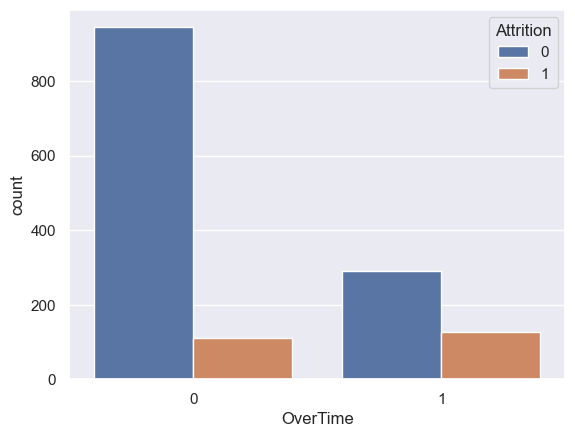

In [101]:
sns.countplot(x="OverTime", hue= "Attrition", data=df)

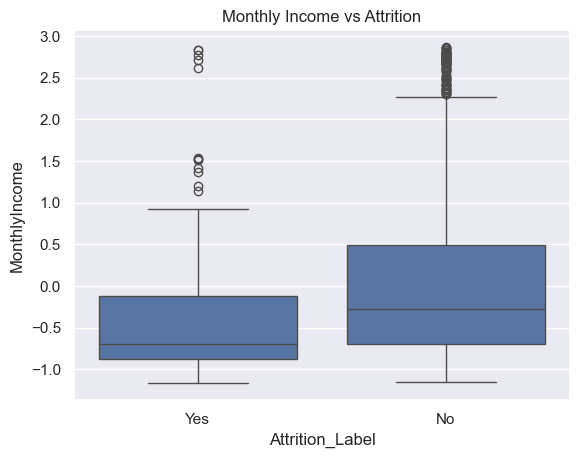

In [102]:
df['Attrition_Label'] = df['Attrition'].map({1:'Yes', 0:'No'})

sns.boxplot(x='Attrition_Label', y='MonthlyIncome', data=df)
plt.title('Monthly Income vs Attrition')
plt.show()

<Axes: xlabel='JobSatisfaction', ylabel='percent'>

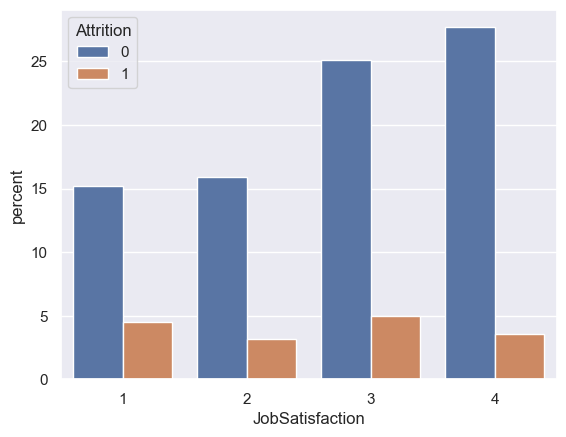

In [103]:
sns.countplot(x="JobSatisfaction", hue="Attrition", stat="percent",data=df)

In [104]:
df_viz = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')
df_model = df

FileNotFoundError: [Errno 2] No such file or directory: 'WA_Fn-UseC_-HR-Employee-Attrition.csv'

In [ ]:
sns.histplot(x="Age", hue="Attrition", data=df_viz, multiple="fill")

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x="WorkLifeBalance", hue="Attrition", data=df_viz, stat="percent")
plt.xticks([0,1,2,3], ["Bad","Good","Better","Best"])
plt.title('Work Life Balance vs Attrition')
plt.show()

In [ ]:
df_viz["WorkLifeBalance"].describe()

In [ ]:
# Calculate attrition rate WITHIN each WLB group
wlb = df_viz.groupby('WorkLifeBalance')['Attrition'].apply(
    lambda x: (x=='Yes').sum() / len(x) * 100
).reset_index()
wlb.columns = ['WorkLifeBalance', 'AttritionRate']
wlb['WorkLifeBalance'] = wlb['WorkLifeBalance'].map({1:'Bad', 2:'Good', 3:'Better', 4:'Best'})

sns.barplot(x='WorkLifeBalance', y='AttritionRate', data=wlb)
plt.title('Attrition Rate by Work Life Balance')
plt.ylabel('Attrition Rate %')
plt.show()

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(df_viz.corr(), annot=False, fmt='0.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
attrition_corr = df.corr()['Attrition'].sort_values(ascending=False)
print(attrition_corr)

In [ ]:
plt.figure(figsize=(10,8))
attrition_corr.drop('Attrition').sort_values().plot(kind='barh', color=['red' if x>0 else 'steelblue' for x in attrition_corr.drop('Attrition').sort_values()])
plt.title('Features Correlation with Attrition')
plt.xlabel('Correlation coefficient')
plt.axvline(x=0, color='black',linewidth=0.5)
plt.tight_layout()
plt.show()

## Training the model

In [ ]:
X= df.drop(columns=['Attrition', 'Attrition_Label'])
y=df['Attrition']

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train,X_test,y_train,y_test= train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
lr=LogisticRegression()
lr.fit(X_train,y_train)

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix

In [ ]:
y_pred=lr.predict(X_test)
print(accuracy_score(y_test,y_pred))

In [ ]:
from sklearn.metrics import classification_report

In [ ]:
cm=confusion_matrix(y_test,y_pred)
sns.heatmap(cm, annot=True,fmt='0.2f',cmap="Blues",xticklabels=["Stayed","Left"], yticklabels=["Stayed","Left"])
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()
print(classification_report(y_test, y_pred))

In [ ]:
pip install imbalanced-learn

## Applying SMOTE

In [ ]:
from imblearn.over_sampling import SMOTE

In [ ]:
smote=SMOTE(random_state=42)
X_train_smote, y_train_smote=smote.fit_resample(X_train,y_train)
print("\n Before SMOTE: ",y_train.value_counts())
print("\n After SMOTE: ",y_train_smote.value_counts())

In [ ]:
lr=LogisticRegression()
lr.fit(X_train_smote,y_train_smote)

In [ ]:
ypred1=lr.predict(X_test)
print(accuracy_score(y_test,ypred1))

In [ ]:
cm=confusion_matrix(y_test,ypred1)
sns.heatmap(cm, annot=True,fmt='0.2f',cmap="Blues",xticklabels=["Stayed","Left"], yticklabels=["Stayed","Left"])
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()
print(classification_report(y_test, ypred1))

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
dt=DecisionTreeClassifier(max_depth=5,random_state=42)
dt.fit(X_train_smote,y_train_smote)

In [ ]:
y_preddt=dt.predict(X_test)
print(accuracy_score(y_test,y_preddt))
print(classification_report(y_test,y_preddt))

In [ ]:
for depth in [3, 4, 5, 6, 7, 8, 10]:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt.fit(X_train_smote, y_train_smote)
    y_pred_dt = dt.predict(X_test)
    recall = classification_report(y_test, y_pred_dt, output_dict=True)['1']['recall']
    print(f"max_depth={depth}, Recall={recall:.2f}")

In [ ]:
from sklearn.svm import SVC
models = {
    'Logistic Regression': LogisticRegression(),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'SVM': SVC()
}

for name, model in models.items():
    model.fit(X_train_smote, y_train_smote)
    y_pred = model.predict(X_test)
    recall = classification_report(y_test, y_pred, output_dict=True)['1']['recall']
    accuracy = accuracy_score(y_test, y_pred)
    print(f"{name} → Accuracy: {accuracy:.2f}, Recall: {recall:.2f}") 

## SHAP Analysis

In [ ]:
pip install shap

In [ ]:
import shap

In [ ]:
explainer = shap.LinearExplainer(lr, X_train_smote)
shap_values = explainer.shap_values(X_test)

In [ ]:
shap.summary_plot(shap_values, X_test, 
                  feature_names=X_test.columns, 
                  plot_type='bar')

In [ ]:
shap.summary_plot(shap_values, X_test, feature_names=X_test.columns)

In [ ]:
# New employee data
new_employee = X_test.iloc[0]  # take one test employee
# Predict probability of leaving
probability = lr.predict_proba(new_employee.values.reshape(1,-1))
print(f"Probability of staying: {probability[0][0]:.2%}")
print(f"Probability of leaving: {probability[0][1]:.2%}")

In [ ]:
# Test on first 5 employees
for i in range(5):
    emp = X_test.iloc[i].values.reshape(1,-1)
    prob = lr.predict_proba(emp)[0][1]
    print(f"Employee {i+1}: {prob:.2%} chance of leaving")

In [ ]:
# Explain Employee 3's prediction
employee_3 = X_test.iloc[2].values.reshape(1,-1)

shap_values_emp3 = explainer.shap_values(X_test.iloc[2:3])

shap.waterfall_plot(shap.Explanation(
    values=shap_values_emp3[0],
    base_values=explainer.expected_value,
    feature_names=X_test.columns.tolist()
))
print(shap_values_emp3)